In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga del Dataset
df = pd.read_csv("djve_argentina_completo.csv")
print("Dimensiones iniciales:", df.shape)
print("\nEstructura de tipos de datos:\n", df.dtypes)
print("---------------------------------------------------------------")
print( df.head(5) )

Dimensiones iniciales: (80400, 12)

Estructura de tipos de datos:
 id_declaracion              int64
fecha_venta                object
puerto_salida              object
requiere_refrigeracion      int64
canal_aduana               object
anio                        int64
producto                   object
pais_destino               object
via_transporte             object
toneladas                 float64
precio_fob_usd_ton        float64
valor_total_usd           float64
dtype: object
---------------------------------------------------------------
   id_declaracion fecha_venta          puerto_salida  requiere_refrigeracion  \
0          100001  2025-05-10  Rosario (San Lorenzo)                       0   
1          100002  2025-12-31  Rosario (San Lorenzo)                       0   
2          100003  2025-11-10   Rosario (San Martín)                       0   
3          100004  2023-05-02   Rosario (San Martín)                       0   
4          100005  2024-04-11  Rosario (San Lor

In [51]:
print("--- PROCESO DE LIMPIEZA ---")

# 1. Detección y eliminación de duplicados
duplicados_cant = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados_cant}")
df.drop_duplicates(inplace=True)

# 2. Identificación de nulos
print("\nValores nulos por columna antes de limpiar:\n", df.isnull().sum())

# Tratamiento: Eliminamos filas sin toneladas (variable crítica) e imputamos puerto
df.dropna(subset=['toneladas'], inplace=True)
df['puerto_salida'].fillna(df['puerto_salida'].mode()[0], inplace=True)

# 3. Conversión correcta de tipos de datos
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['requiere_refrigeracion'] = df['requiere_refrigeracion'].astype('category')
df['canal_aduana'] = df['canal_aduana'].astype('category')

# 4. Extracción de características temporales (Feature Engineering)
df['anio'] = df['fecha_venta'].dt.year
df['mes'] = df['fecha_venta'].dt.month
df['trimestre'] = df['fecha_venta'].dt.quarter

print(f"\nDimensiones finales tras limpieza: {df.shape}")

--- PROCESO DE LIMPIEZA ---
Filas duplicadas encontradas: 400

Valores nulos por columna antes de limpiar:
 id_declaracion              0
fecha_venta                 0
puerto_salida             400
requiere_refrigeracion      0
canal_aduana                0
anio                        0
producto                    0
pais_destino                0
via_transporte              0
toneladas                 960
precio_fob_usd_ton          0
valor_total_usd             0
dtype: int64

Dimensiones finales tras limpieza: (79040, 14)


In [52]:
#4 . Visualizaciones 


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


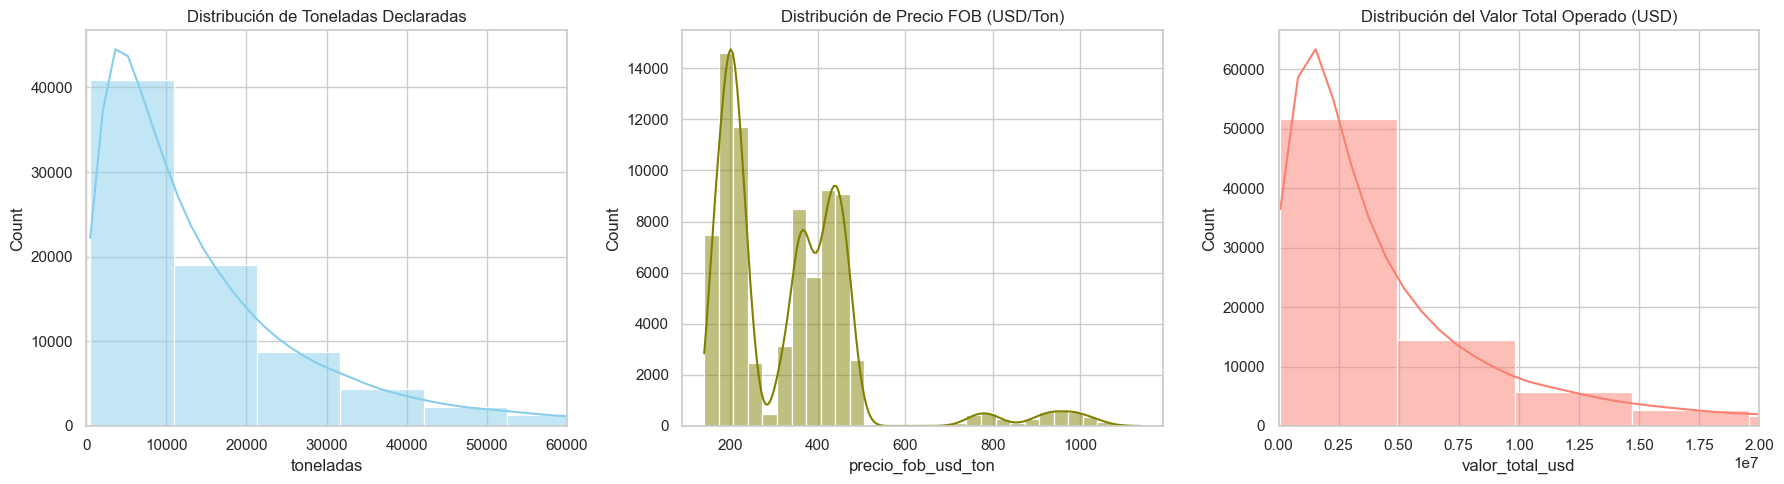

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='toneladas', kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Distribución de Toneladas Declaradas')
axes[0].set_xlim(0, 60000) # Acotamos visualmente por sesgo de la exponencial

sns.histplot(data=df, x='precio_fob_usd_ton', kde=True, ax=axes[1], color='olive', bins=30)
axes[1].set_title('Distribución de Precio FOB (USD/Ton)')

sns.histplot(data=df, x='valor_total_usd', kde=True, ax=axes[2], color='salmon', bins=30)
axes[2].set_title('Distribución del Valor Total Operado (USD)')
axes[2].set_xlim(0, 2e7)

plt.tight_layout()
plt.show()

In [54]:
# BoxPlots

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


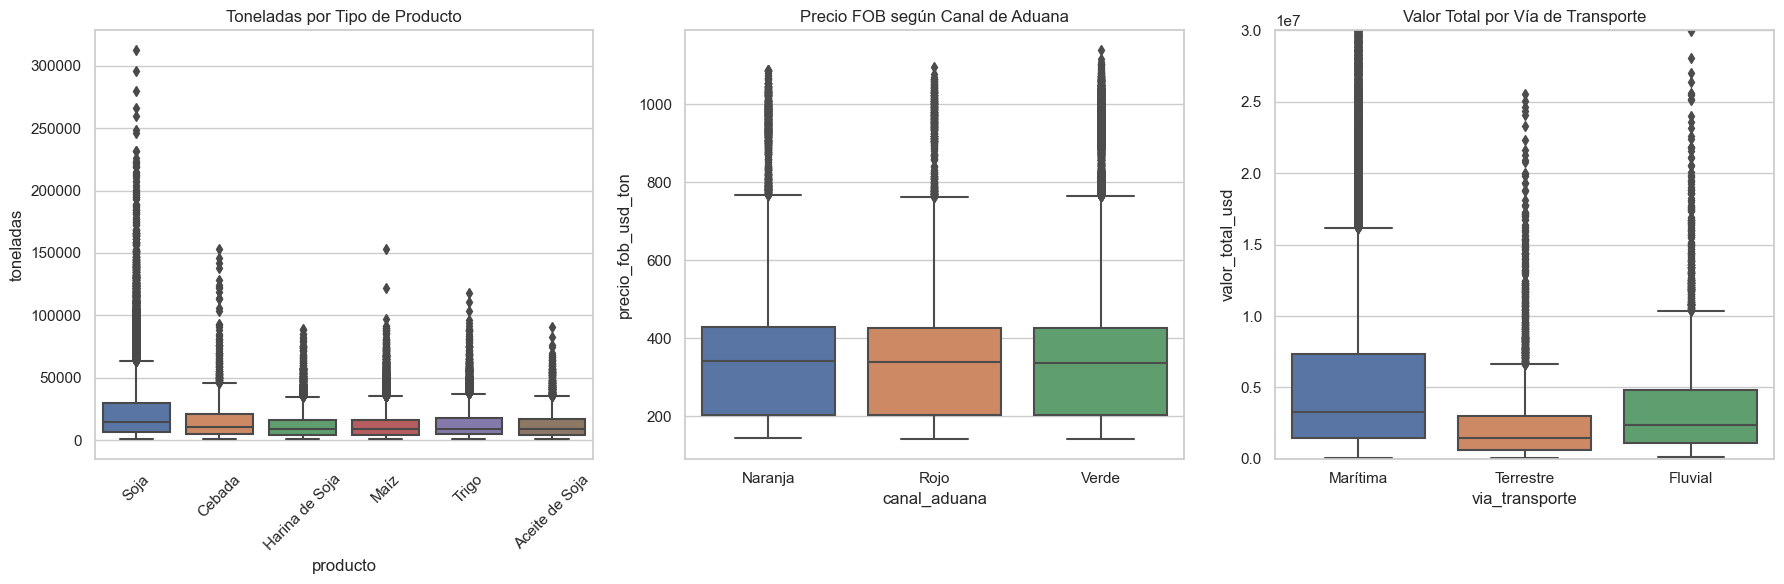

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df, y='toneladas', x='producto', ax=axes[0])
axes[0].set_title('Toneladas por Tipo de Producto')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, y='precio_fob_usd_ton', x='canal_aduana', ax=axes[1])
axes[1].set_title('Precio FOB según Canal de Aduana')

sns.boxplot(data=df, y='valor_total_usd', x='via_transporte', ax=axes[2])
axes[2].set_title('Valor Total por Vía de Transporte')
axes[2].set_ylim(0, 3e7)

plt.tight_layout()
plt.show()

In [56]:
# scatterPlots

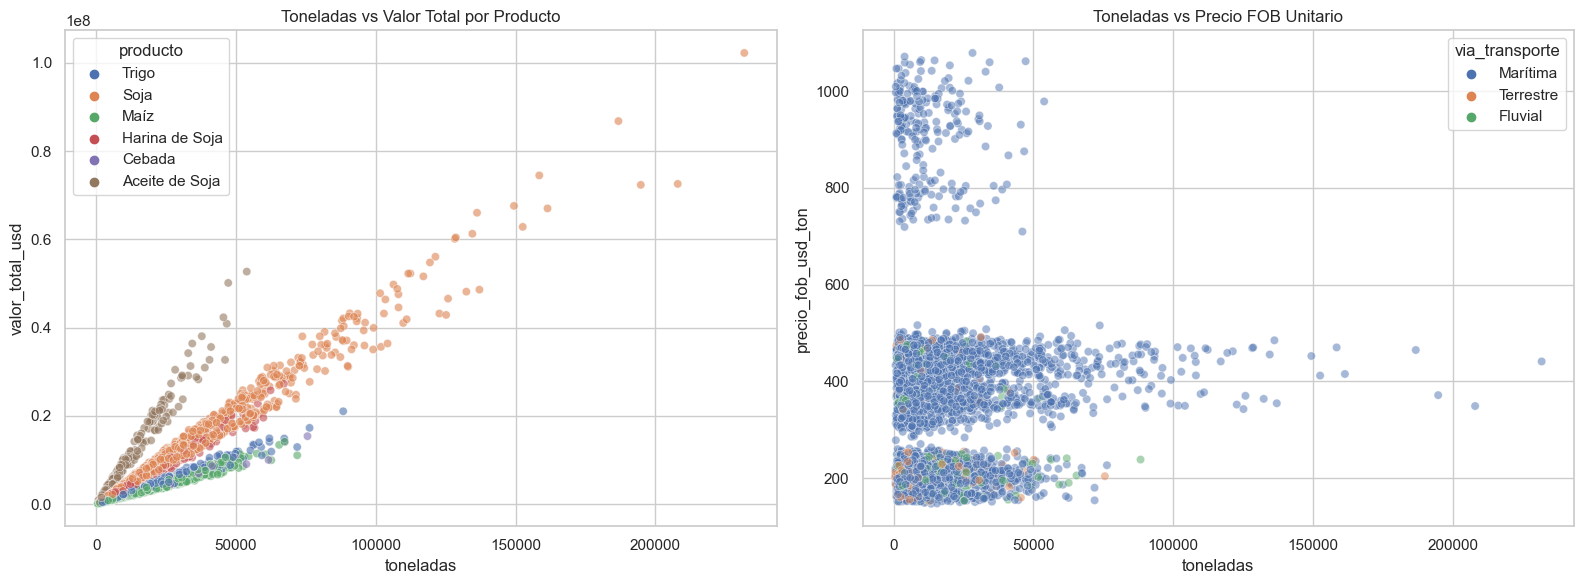

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Muestreamos 5000 filas para evitar saturar el gráfico
df_sample = df.sample(5000, random_state=42)

sns.scatterplot(data=df_sample, x='toneladas', y='valor_total_usd', hue='producto', alpha=0.6, ax=axes[0])
axes[0].set_title('Toneladas vs Valor Total por Producto')

sns.scatterplot(data=df_sample, x='toneladas', y='precio_fob_usd_ton', hue='via_transporte', alpha=0.5, ax=axes[1])
axes[1].set_title('Toneladas vs Precio FOB Unitario')

plt.tight_layout()
plt.show()

In [58]:
#Vis Adicionales

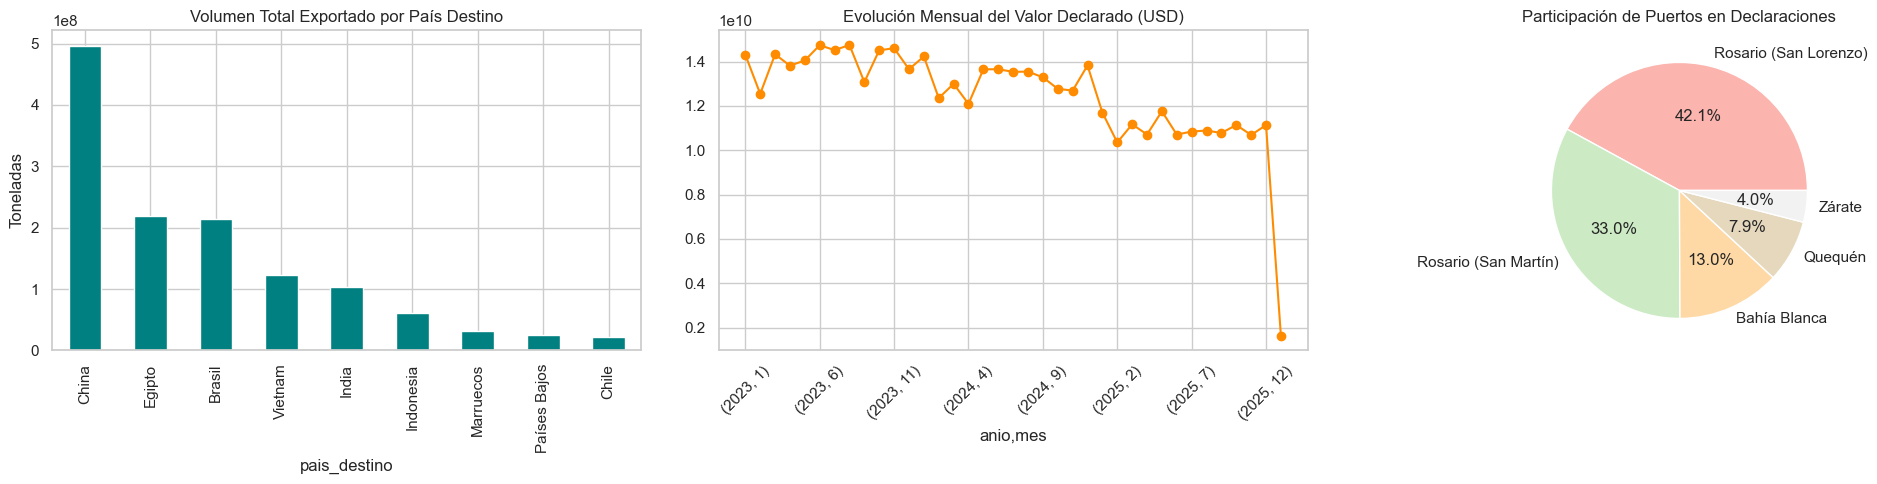

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: Barras - Total exportado por país de destino
df.groupby('pais_destino')['toneladas'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Volumen Total Exportado por País Destino')
axes[0].set_ylabel('Toneladas')

# Gráfico 2: Líneas - Evolución mensual de exportaciones (Tendencia)
df.groupby(['anio', 'mes'])['valor_total_usd'].sum().plot(kind='line', marker='o', ax=axes[1], color='darkorange')
axes[1].set_title('Evolución Mensual del Valor Declarado (USD)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# Gráfico 3: Torta - Participación de Puertos de Salida
df['puerto_salida'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[2], cmap='Pastel1')
axes[2].set_title('Participación de Puertos en Declaraciones')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [60]:
# analisi por tipo de transporte 


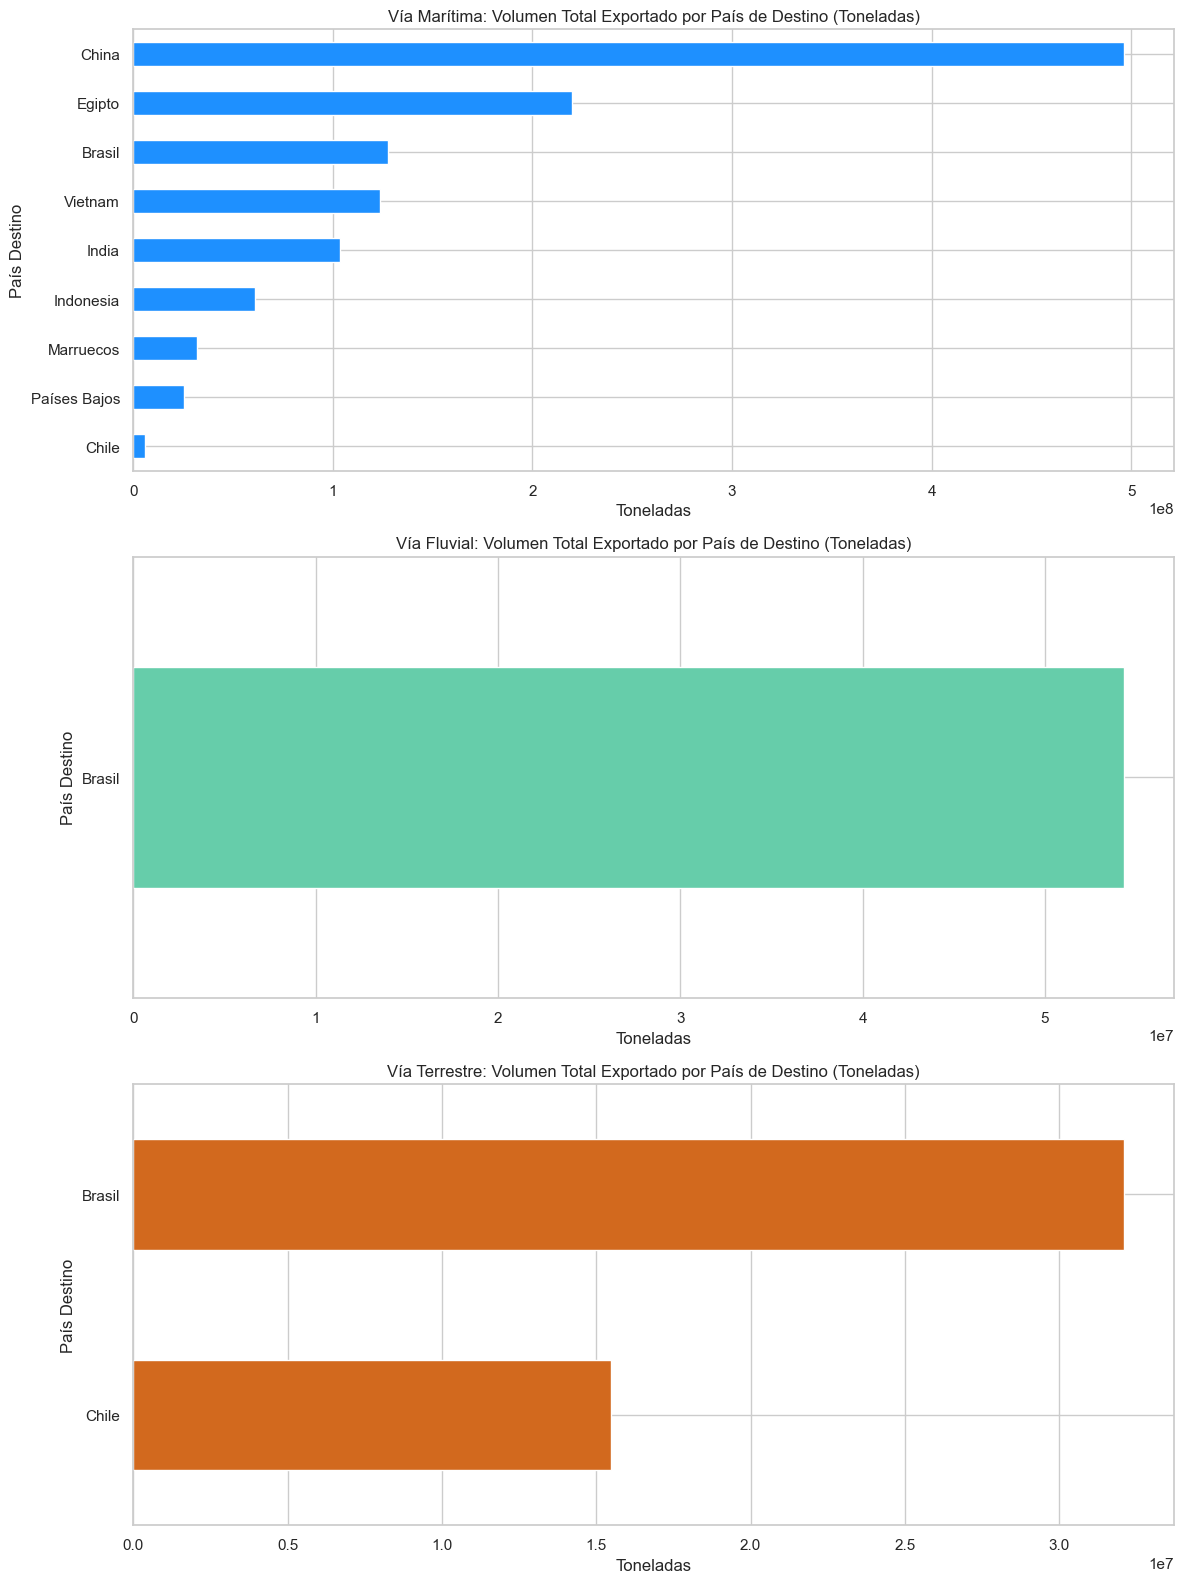

In [61]:
# Configurar una figura con 3 subgráficos (uno para cada vía de transporte)
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Filtrar y graficar para la Vía Marítima
df_maritimo = df[df['via_transporte'] == 'Marítima']
df_maritimo.groupby('pais_destino')['toneladas'].sum().sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='dodgerblue'
)
axes[0].set_title('Vía Marítima: Volumen Total Exportado por País de Destino (Toneladas)')
axes[0].set_xlabel('Toneladas')
axes[0].set_ylabel('País Destino')

# Filtrar y graficar para la Vía Fluvial
df_fluvial = df[df['via_transporte'] == 'Fluvial']
df_fluvial.groupby('pais_destino')['toneladas'].sum().sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='mediumaquamarine'
)
axes[1].set_title('Vía Fluvial: Volumen Total Exportado por País de Destino (Toneladas)')
axes[1].set_xlabel('Toneladas')
axes[1].set_ylabel('País Destino')

# Filtrar y graficar para la Vía Terrestre
df_terrestre = df[df['via_transporte'] == 'Terrestre']
df_terrestre.groupby('pais_destino')['toneladas'].sum().sort_values(ascending=True).plot(
    kind='barh', ax=axes[2], color='chocolate'
)
axes[2].set_title('Vía Terrestre: Volumen Total Exportado por País de Destino (Toneladas)')
axes[2].set_xlabel('Toneladas')
axes[2].set_ylabel('País Destino')

plt.tight_layout()
plt.show()